In [464]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from george import kernels
import george
import scipy.optimize as op

In [465]:
def der(xy):
    """
    Compute the numerical derivative of a function given y-values and their corresponding x-values.

    Parameters
    ----------
    xy : array-like, shape (2, N)
        A two-element list or array where:
        - xy[0] contains the y-values,
        - xy[1] contains the corresponding x-values.

    Returns
    -------
    ndarray, shape (2, N-1)
        A two-row array:
        - Row 0: dy/dx (the finite difference derivative),
        - Row 1: midpoints of x (used as the new x positions of the derivative).
    """
    xder, yder = xy[1], xy[0]
    return np.array([np.diff(yder) / np.diff(xder), xder[:-1] + np.diff(xder) * 0.5])


def smoothness_gen(x, y, gp):
    """
    Generate a smoothness penalty term from a GP-predicted function.

    This function applies a second derivative estimate to a Gaussian Process (GP)
    prediction of y-values at positions x, and computes a scalar penalty measuring
    the total curvature or roughness of the prediction.

    Parameters
    ----------
    x : ndarray
        Input x-values.
    y : ndarray
        Observed y-values.
    gp : george.GP
        A Gaussian Process object from the `george` package.

    Returns
    -------
    float
        The total smoothness penalty, computed as the sum of the absolute
        second derivative values of the GP-predicted curve.
    """
    return np.nansum(np.abs(der(der([gp.predict(y, x)[0], x]))), axis=1)[0]
    
def nll(p, y, x, gp, s):
    """
    Compute the negative log-likelihood (NLL) with a smoothness regularization term.

    The function sets the GP kernel parameters, evaluates the likelihood of the
    data under the GP model, and penalizes non-smooth predictions using a tunable
    power-law penalty on second derivatives.

    Parameters
    ----------
    p : ndarray
        The kernel hyperparameter vector to set in the GP.
    y : ndarray
        The observed data values.
    x : ndarray
        The x-values corresponding to `y`.
    gp : george.GP
        A Gaussian Process object from the `george` package.
    s : float
        Smoothness exponent; larger values increase the penalty on rough solutions.

    Returns
    -------
    float
        The negative log-likelihood, regularized by the smoothness term.
        Returns a large penalty (1e25) if numerical instability or NaN is encountered.
    """
    gp.kernel.parameter_vector = p

    try:
        smoothness = smoothness_gen(x, y, gp)
        smoothness = smoothness if np.isfinite(smoothness) \
                                   and ~np.isnan(smoothness) else 1e25
    except np.linalg.LinAlgError:
        smoothness = 1e25

    ll = gp.log_likelihood(y, quiet=True)  # - (smoothness) #np.sum((y - pred[inds]**2)) #
    ll -= smoothness ** s

    # print('smoothness is ', smoothness)

    # print (p, -ll if np.isfinite(ll) else 1e25)
    return -ll if np.isfinite(ll) else 1e25

In [466]:
# Reading an example light curve of a CV
t, m, merr = np.loadtxt('./../lc_example/OGLE-BLG-DN-0001.dat', unpack=True)

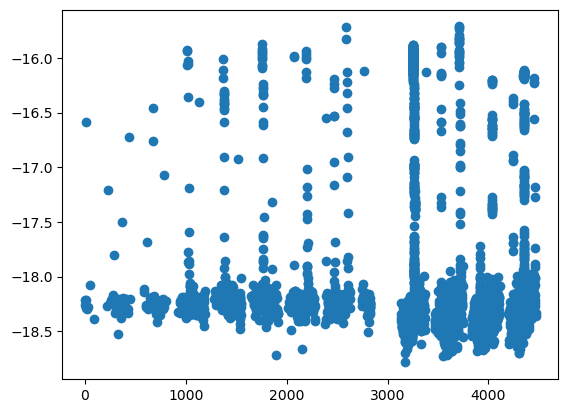

In [467]:
plt.scatter(t-min(t), -m)
# plt.xlim(-1,2000)

In [468]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

# --- 1. Sample light curve data (replace this with your real data) ---
# Example: time = np.array([...]), mag = np.array([...])
# Replace the following with your data
# time, mag = np.loadtxt('your_lightcurve_file.txt', unpack=True)

# Dummy placeholders (remove when using real data)
time = t-min(t)
mag = m

# --- 2. Invert magnitude to detect peaks as maxima ---
inv_mag = -mag

# --- 3. Find peaks ---
peaks = detect_peaks_derivative(time, inv_mag)

# --- 4. Gaussian model ---
def gaussian(x, a, x0, sigma, offset):
    return offset - a * np.exp(-(x - x0)**2 / (2 * sigma**2))

# --- 5. Fit and plot each peak ---
plt.figure(figsize=(10, 6))
plt.plot(time, mag, label='Light Curve', zorder=1)

print('Found %i peaks'%len(peaks))
# for peak in peaks:
    # Limit the fit range around each peak
    # i0 = max(peak - 20, 0)
    # i1 = min(peak + 20, len(time))
    # x_peak = time[i0:i1]
    # y_peak = mag[i0:i1]

    # # Initial guess for Gaussian parameters
    # a0 = np.max(y_peak) - np.min(y_peak)
    # x0 = time[peak]
    # sigma0 = (time[i1-1] - time[i0]) / 6
    # offset0 = np.median(y_peak)

    # popt, _ = curve_fit(gaussian, x_peak, y_peak, p0=[a0, x0, sigma0, offset0])
    # fit_curve = gaussian(x_peak, *popt)
    # plt.plot(x_peak, fit_curve, '--', zorder=2)
    # plt.axvline(peak)


plt.gca().invert_yaxis()
plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.title("Gaussian Fits to CV Light Curve Peaks")
plt.show()


IndentationError: expected an indented block after 'for' statement on line 30 (1177510751.py, line 49)

In [274]:
# Defining a Gaussian template for the variability in the light curve
x = np.linspace(0,100)
norm_pdf = 25*(norm(loc = 35, scale = 5).pdf(x))

[None, None, None, None, None, None]

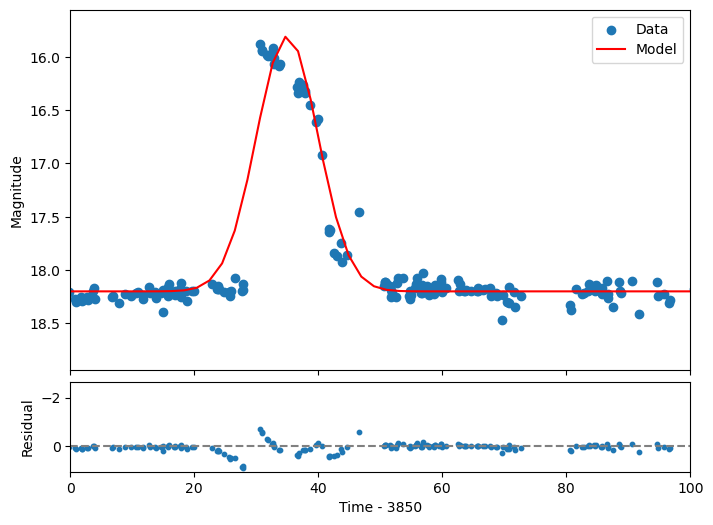

In [275]:
model = -1.2 * norm_pdf + 18.2

# Interpolate model to data points (assuming x and t-3850 are aligned in range)
from scipy.interpolate import interp1d
model_interp = interp1d(x, model, kind='linear', bounds_error=False, fill_value='extrapolate')
residuals = m - model_interp(t - 3850)

# Set up the figure and subplots
fig = plt.figure(figsize=(8, 6))
gs = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.05)

# Top plot: light curve
ax0 = fig.add_subplot(gs[0])
ax0.scatter(t - 3850, m, label='Data')
ax0.plot(x, model, color='r', label='Model')
ax0.set_xlim(0, 100)
ax0.invert_yaxis()
ax0.legend()
ax0.set_ylabel('Magnitude')

# Bottom plot: residuals
ax1 = fig.add_subplot(gs[1], sharex=ax0)
ax1.scatter(t - 3850, residuals, s=10)
ax1.axhline(0, color='gray', linestyle='--')
ax1.set_xlim(0, 100)
ax1.set_ylabel('Residual')
ax1.set_xlabel('Time - 3850')
ax1.invert_yaxis()  # Optional, if you want residuals to be in magnitude scale

# Remove x-axis labels on top plot
plt.setp(ax0.get_xticklabels(), visible=False)

In [276]:
# Defining the GP kernel
kernel = kernels.Product(kernels.ConstantKernel(1.10), kernels.ExpSquaredKernel(1.73))
gp = george.GP(kernel)

In [277]:
# Isolating a single peak in the light curve
ind_fit = ((t - 3850)<100) & ((t - 3850)>0)
t_fit = (t - 3850)[ind_fit]
m_fit = m[ind_fit]
err_fit = merr[ind_fit]
res_fit = residuals[ind_fit]

In [278]:
# Optimizing parameters of the GP
# s determines the smoothness of the fit, larger s= smoother curve
gp.compute(t_fit, err_fit)
p0 = gp.kernel.parameter_vector
s = 2
results = op.minimize(nll, [p0[0], p0[1]],
                      args=(res_fit,
                            t_fit, gp, s))
# Update the kernel and print the final log-likelihood.
gp.kernel.parameter_vector = results.x

In [279]:
# Predicting on a new time sampling

t_fit_new = np.linspace(0,100, 1000)
model_interp_new = model_interp(t_fit_new)
mu, cov = gp.predict(res_fit, t_fit_new)
std = np.sqrt(np.diag(cov))

In [280]:
gp.kernel.parameter_vector

array([-3.75882045,  0.77481125])

Text(0, 0.5, 'Magnitude')

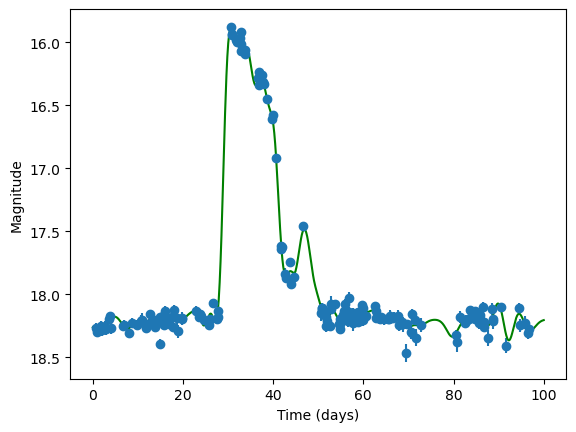

In [281]:
plt.errorbar(t_fit, m_fit, yerr=err_fit, fmt='o', label='Data')
plt.plot(t_fit_new, mu+model_interp_new, color='g', label='GP fit')

plt.gca().invert_yaxis()

plt.xlabel('Time (days)')
plt.ylabel('Magnitude')

In [285]:
merr

array([0.069, 0.039, 0.011, ..., 0.03 , 0.034, 0.035], shape=(9776,))

In [287]:
np.linspace(1, 50, 50)

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
       14., 15., 16., 17., 18., 19., 20., 21., 22., 23., 24., 25., 26.,
       27., 28., 29., 30., 31., 32., 33., 34., 35., 36., 37., 38., 39.,
       40., 41., 42., 43., 44., 45., 46., 47., 48., 49., 50.])

In [470]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.ndimage import minimum_filter

# --- Generate example multi-peak data ---
def true_model(x):
    return (
        2 * np.exp(-((x - 2) ** 2) / (2 * 0.2**2)) +
        1.5 * np.exp(-((x - 5) ** 2) / (2 * 0.3**2)) +
        1.0 * np.exp(-((x - 8) ** 2) / (2 * 0.4**2))
    )

x = t
y = m
yerr = merr

# --- Gaussian with fixed mu and sigma ---
def gaussian_fixed_params(x, amp, mu, sigma):
    return amp * 25* np.exp(-(x - mu)**2 / (2 * sigma**2)) + 18.2

# --- Grid search setup ---
mu_vals = np.linspace(min(x), max(x), 200)
sigma_vals = np.linspace(1, 50, 50)
fit_scores = np.full((len(mu_vals), len(sigma_vals)), np.inf)  # initialize with inf
fit_scores_local = np.full((len(mu_vals), len(sigma_vals)), np.inf)  # initialize with inf

last_peak = []
# --- Perform grid search using curve_fit in a local window ---
for i, mu in enumerate(mu_vals):
    for j, sigma in enumerate(sigma_vals):
        # restrict x to local window
        mask = (x >= mu - 2*sigma) & (x <= mu + 2*sigma)
        if np.sum(mask) < 5:
            continue  # skip if too few points

        x_local, y_local, y_err_local = x[mask], y[mask], yerr[mask]

        try:
            # fit amplitude only
            amp = np.min(y_local)-18.2
            if amp > -0.1:
                pass
            popt, _ = curve_fit(lambda x, amp, mu, sigma: gaussian_fixed_params(x, amp, mu, sigma),
                                x_local, y_local, p0=[np.max(y_local), mu, sigma], sigma=y_err_local, maxfev=1000)
            amp_fit = popt[0]
            y_fit = gaussian_fixed_params(x, amp_fit, mu, sigma)
            y_fit_local = gaussian_fixed_params(x_local, amp_fit, mu, sigma)
            score = np.sum(((y - y_fit) ** 2)/(yerr**2))/(len(y)-3+1)
            score_local = np.sum(((y_local - y_fit_local) ** 2)/(y_err_local**2))/(len(y_local)-3+1)
            fit_scores[i, j] = score
            fit_scores_local[i, j] = score_local
            # if mu>7.7:
            #     last_peak.append([popt, score])
                
        except RuntimeError:
            continue


/var/folders/6f/k2kn3hn52ws4kc_w0_zqfpy40000gp/T/ipykernel_28070/53346593.py:44: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(lambda x, amp, mu, sigma: gaussian_fixed_params(x, amp, mu, sigma),


In [471]:
# --- Filter good fits by score threshold ---
valid_scores = fit_scores[np.isfinite(fit_scores)]
# valid_scores_local = fit_scores_local[np.isfinite(fit_scores_local)]
lin_fit = np.sum((m-np.median(m))**2/merr**2)/len(y)
gauss_fits = fit_scores/lin_fit

compare_to_1 = np.abs(fit_scores_local - 1)

threshold = 1 #np.percentile(valid_scores, 1)  # you can change the threshold percent
threshold2 = np.percentile(valid_scores, 40)
peaks_mask = (gauss_fits < threshold) & (fit_scores<threshold2) #& (compare_to_1<0.03)
best_indices = np.argwhere(peaks_mask)


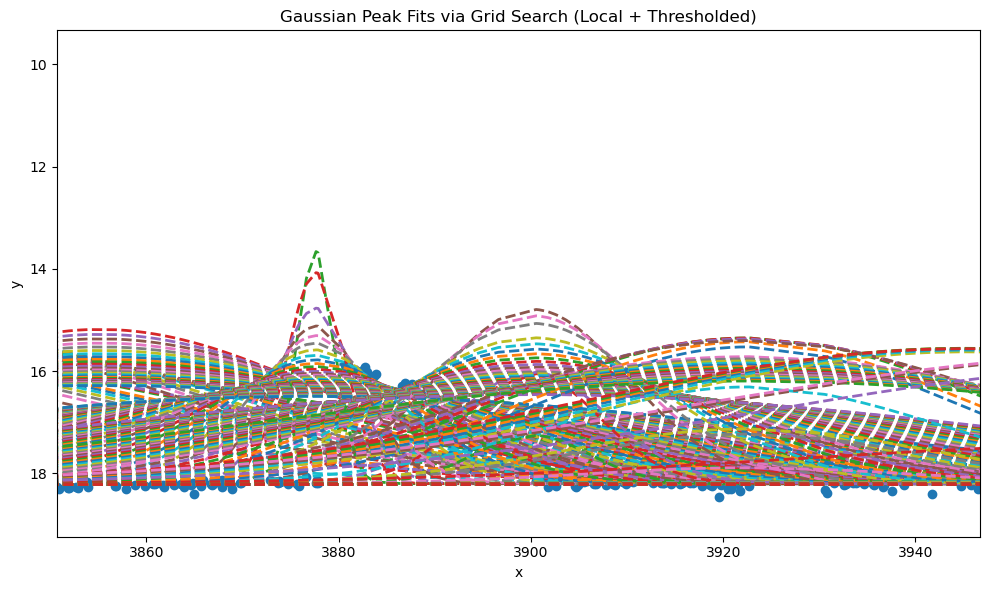

In [473]:
# --- Plot ---
plt.figure(figsize=(10, 6))
plt.scatter(x, y, label='Data', lw=1)

for i, j in best_indices:
    mu = mu_vals[i]
    sigma_ = sigma_vals[j]

    # score_local_to_1 = compare_to_1[i, j]
    # if score_local_to_1>0.03:
    #     continue
    # else:
    #     print(mu, sigma)

    # fit again locally to plot the best Gaussian
    mask = (x >= mu - 2*sigma_) & (x <= mu + 2*sigma_)
    x_local, y_local, y_err_local = x[mask], y[mask], yerr[mask]

    amp = np.min(y_local)-18.2

    amp_fitted = curve_fit(lambda x, amp: gaussian_fixed_params(x, amp, mu, sigma_),
                    x_local, y_local, p0=[amp], sigma=y_err_local, maxfev=1000)[0][0]
    y_peak = gaussian_fixed_params(x, amp_fitted, mu, sigma_)
    plt.plot(x, y_peak, '--', lw=2, label=f'μ={mu:.2f}, σ={sigma:.2f}, A={amp:.2f}')

plt.title('Gaussian Peak Fits via Grid Search (Local + Thresholded)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(t[ind_fit][0], t[ind_fit][-1])
# plt.legend()
plt.tight_layout()
plt.gca().invert_yaxis()

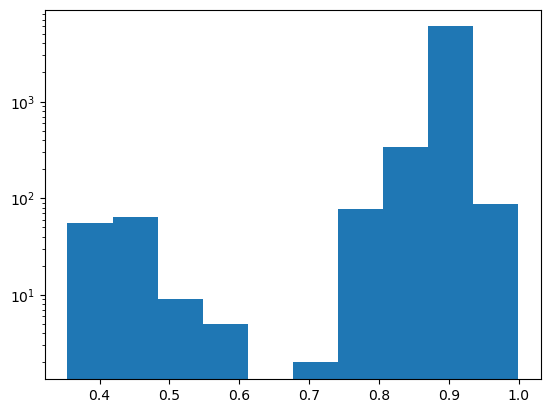

In [305]:
lin_fit = np.sum((m-np.median(m))**2/merr**2)/len(y)
gauss_fits = fit_scores.flatten()[np.isfinite(fit_scores.flatten())]/lin_fit
plt.hist(gauss_fits[gauss_fits<1])
plt.yscale('log')

25
[2.528 2.39  2.385 2.381 2.37  2.35  2.33  2.323 2.277 2.201 2.115 2.08
 2.071 2.056 2.021 2.001 1.757 1.752 1.693 1.616 1.399 1.363 0.564 0.551
 0.537]


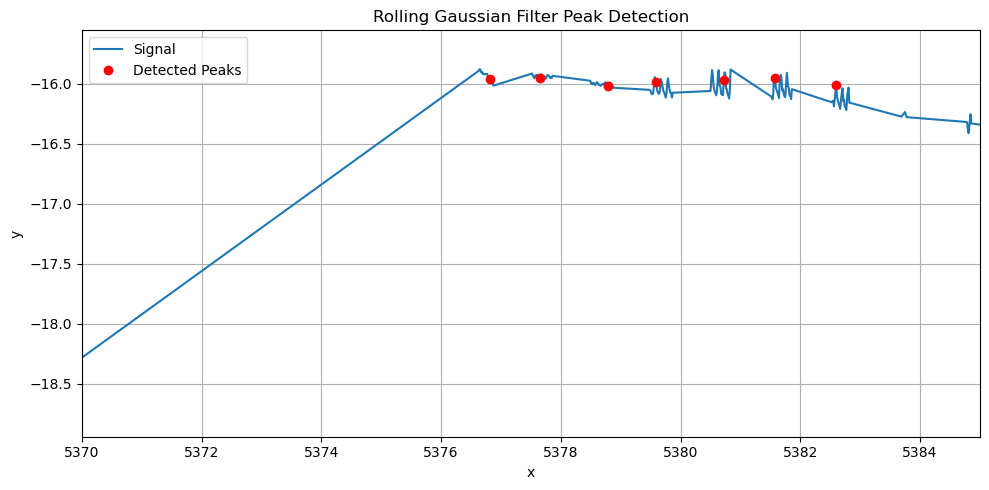

In [459]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import correlate1d
from scipy.stats import median_abs_deviation

def rolling_gaussian_peak_finder(x, y, window_size=31, sigma=5, threshold=0.5, min_distance_days=1.0):
    """
    Detects peaks using a rolling Gaussian template filter.
    """
    # Build a manual Gaussian template
    t = np.linspace(-window_size//2, window_size//2, window_size)
    template = np.exp(-t**2 / (2 * sigma**2))
    template = template / np.linalg.norm(template)

    # Normalize the signal
    y_norm = (y - np.median(y)) / median_abs_deviation(y)

    # Compute correlation score
    match_scores = correlate1d(y_norm, template, mode='reflect')

    # Detect peaks in match score
    peaks, _ = find_peaks(match_scores, height=threshold)


    # Now apply non-maximum suppression based on time distance
    filtered_peaks = []
    peaks = sorted(peaks, key=lambda i: y[i], reverse=True)  # sort by y-height

    used = np.zeros(len(x), dtype=bool)

    for idx in peaks:
        if used[idx]:
            continue
        filtered_peaks.append(idx)
        # Mark all nearby points within min_distance_days as used
        nearby = np.where(np.abs(x - x[idx]) < min_distance_days)[0]
        used[nearby] = True

    return np.array(filtered_peaks), match_scores

# --- Example signal ---
x = t #np.linspace(0, 10, 1000)
# true_peaks = [2, 5, 7.5]
y = -1*m #sum(np.exp(-((x - mu)**2) / (2 * 0.1**2)) for mu in true_peaks)
# y += np.random.normal(0, 0.05, len(x))

# --- Apply rolling Gaussian filter ---
peaks, scores = rolling_gaussian_peak_finder(x, y, window_size=31, sigma=20, threshold=1, min_distance_days=.5)
ind = np.where(np.abs(y[peaks]-np.median(y))>0.5)
peaks = peaks[ind]
print(len(peaks))
# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Signal')
plt.plot(x[peaks], y[peaks], 'ro', label='Detected Peaks')
print(np.abs(y[peaks]-np.median(y)))
plt.title("Rolling Gaussian Filter Peak Detection")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.xlim(5370, 5385)
plt.show()


In [461]:
peaks = sorted(peaks, key=lambda i: x[i])

In [462]:
np.diff(x[peaks])

array([279.10123, 151.76323, 577.38295,  10.87187, 349.08922, 385.76684,
         0.97331, 710.29515, 124.72392, 654.21838,   0.82371,   1.13758,
         0.79927,   1.13761,   0.8513 ,   1.02588,  10.19569, 262.99769,
       177.78296, 208.33631, 116.71415, 211.20159, 103.93115, 106.76549])

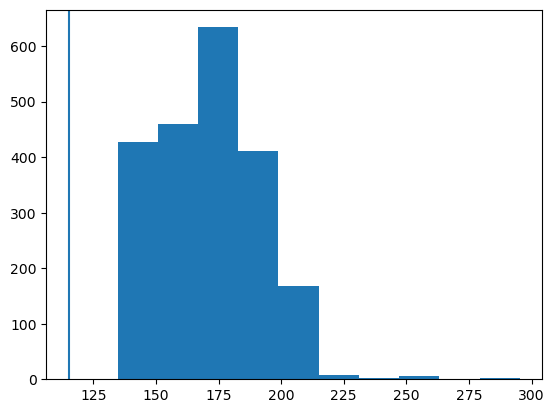

In [267]:
# plt.hist(fit_scores.flatten())
plt.hist(last_peak_scores[last_peak_scores<300])
plt.axvline(threshold)

In [463]:
np.zeros(len(x), dtype=bool)

array([False, False, False, ..., False, False, False], shape=(9776,))

In [259]:
last_peak_scores = np.array([last_peak[i][1] for i in range(len(last_peak))])

(array([2.165e+03, 0.000e+00, 3.000e+00, 4.000e+00, 2.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 2.000e+00, 2.000e+00]),
 array([1.34633023e+02, 7.50680758e+04, 1.50001519e+05, 2.24934961e+05,
        2.99868404e+05, 3.74801847e+05, 4.49735290e+05, 5.24668732e+05,
        5.99602175e+05, 6.74535618e+05, 7.49469061e+05]),
 <BarContainer object of 10 artists>)

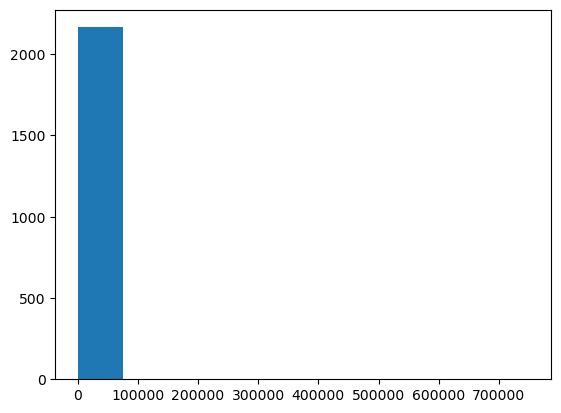

In [264]:
plt.hist(last_peak_scores[np.isfinite(last_peak_scores)])

In [265]:
max(last_peak_scores)

np.float64(749469.0607177626)